<a href="https://colab.research.google.com/github/TAUforPython/LLM_AI_agents/blob/main/lesson-6_MultyAgent_Critical_and_Coordinator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Agent Systems

**Goal:** Build a complete Multi-Agent system for airline customer service using the τ-bench domain.

**Practice structure:**

| Part | Topic | What we build |
|------|-------|---------------|
| 0 | Environment Setup | Dependencies, model, τ-bench database and tools |
| 1 | Single Agent with TAO Loop | ReAct agent on LangGraph |
| 2 | Multi-Agent Hierarchical System | Coordinator + specialized agents |
| 3 | Critics and Quality Control | CriticAgent + Reflexion pattern |
| 4 | Benchmark and Comparison | Measuring architecture performance |

**What we build:** CriticAgent with structured feedback + EnhancedCoordinator with revision loop.

In [1]:
# Install dependencies
!pip install -q langchain-openai langchain-core langgraph pydantic typing-extensions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.7 MB/s eta 0:00:00


In [2]:
import os
import json
import time
import copy
from typing import List, Literal
from pydantic import BaseModel, Field
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

In [4]:
MODEL_NAME = 'gpt-5-nano'

import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# Connection check
test_response = llm.invoke([HumanMessage(content='Reply with one word: working?')])
print(f'Model: {MODEL_NAME}')
print(f'Test: {test_response.content}')
print('Setup complete!')

Model: gpt-5-nano
Test: Yes
Setup complete!


In [39]:
!pip install langchain_mistralai -q

In [50]:
MODEL_NAME = 'mistral-small-latest' # or "mistral-large-latest"

import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

In [51]:
test_response = llm.invoke([HumanMessage(content="Reply with one word: working?")])
print(f"✅ Test response: {test_response.content}")
print("🚀 Setup complete!")

✅ Test response: Working.
🚀 Setup complete!


# MEDICAL DATABASE

In [52]:
DOCTORS_DB = [
    {
        'doctor_id': 'CARD-001',
        'name': 'Dr. Sarah Johnson',
        'specialty': 'Cardiology',
        'location': 'Downtown Clinic',
        'qualification': 'MD, Board Certified Cardiologist',
        'experience_years': 15,
        'available_dates': ['2026-04-15', '2026-04-16', '2026-04-17'],
        'available_times': {
            '2026-04-15': ['09:00', '10:30', '14:00'],
            '2026-04-16': ['08:30', '11:00', '15:30'],
            '2026-04-17': ['10:00', '13:00', '16:00'],
        },
        'fee': 200,
        'duration_minutes': 45,
    },
    {
        'doctor_id': 'PED-001',
        'name': 'Dr. James Wilson',
        'specialty': 'Pediatrics',
        'location': 'Children\'s Health Center',
        'qualification': 'MD, Pediatric Specialist',
        'experience_years': 12,
        'available_dates': ['2026-04-15', '2026-04-16', '2026-04-17'],
        'available_times': {
            '2026-04-15': ['08:00', '09:30', '14:15'],
            '2026-04-16': ['07:30', '11:00', '15:00'],
            '2026-04-17': ['09:00', '12:30', '17:00'],
        },
        'fee': 120,
        'duration_minutes': 30,
    },
    {
        'doctor_id': 'DERM-001',
        'name': 'Dr. Olivia Martinez',
        'specialty': 'Dermatology',
        'location': 'Skin Care Center',
        'qualification': 'MD, Dermatology Specialist',
        'experience_years': 8,
        'available_dates': ['2026-04-16', '2026-04-17'],
        'available_times': {
            '2026-04-16': ['10:00', '11:30', '15:00'],
            '2026-04-17': ['09:00', '13:00', '16:30'],
        },
        'fee': 160,
        'duration_minutes': 30,
    },
    {
        'doctor_id': 'GP-001',
        'name': 'Dr. Michael Chen',
        'specialty': 'General Practice',
        'location': 'Family Medicine Clinic',
        'qualification': 'MD, Family Medicine',
        'experience_years': 10,
        'available_dates': ['2026-04-15', '2026-04-16', '2026-04-17'],
        'available_times': {
            '2026-04-15': ['08:00', '10:00', '14:00'],
            '2026-04-16': ['09:00', '12:00', '16:00'],
            '2026-04-17': ['07:30', '11:00', '15:00'],
        },
        'fee': 100,
        'duration_minutes': 25,
    },
]

APPOINTMENTS_DB = {
    'AP-123': {
        'appointment_id': 'AP-123',
        'patient_id': 'P-1234',
        'doctor_id': 'CARD-001',
        'patient_name': 'Ivan Petrov',
        'contact_email': 'ivan@example.com',
        'appointment_date': '2026-04-15',
        'appointment_time': '09:00',
        'specialty': 'Cardiology',
        'status': 'confirmed',
        'reason': 'routine checkup',
    },
    'AP-456': {
        'appointment_id': 'AP-456',
        'patient_id': 'P-5678',
        'doctor_id': 'PED-001',
        'patient_name': 'Anna Smith',
        'contact_email': 'anna@example.com',
        'appointment_date': '2026-04-16',
        'appointment_time': '08:00',
        'specialty': 'Pediatrics',
        'status': 'confirmed',
        'reason': 'vaccination',
    },
}

MEDICAL_POLICIES_DB = {
    'cancellation': {
        'allowed': True,
        'fee': 30,
        'deadline_hours': 24,
        'description': 'Appointments can be canceled up to 24 hours before the scheduled time. A $30 fee applies. Emergency situations (hospitalization, accident) are exempt from fees with proper documentation.',
    },
    'rescheduling': {
        'allowed': True,
        'fee': 20,
        'deadline_hours': 48,
        'description': 'Rescheduling is allowed up to 48 hours before the appointment. A $20 fee applies. Same-day rescheduling is not permitted unless for emergency reasons.',
    },
    'prescriptions': {
        'refill_period': 90,
        'advance_notice': 48,
        'controlled_substances_review': 90,
        'description': 'Prescription refills require 48-hour advance notice. Controlled substances require an in-person visit every 90 days. Chronic medications may be prescribed for up to 90 days.',
    },
    'insurance': {
        'verification_required': True,
        'prior_authorization': 'specialist referrals, diagnostic procedures',
        'copayment': 'varies by plan',
        'description': 'All patients must provide valid insurance information at registration. Prior authorization is required for specialist referrals and diagnostic procedures.',
    },
}


_APPOINTMENTS_SNAPSHOT = copy.deepcopy(APPOINTMENTS_DB)


def reset_db():
    """Reset DB to initial state (undo any rescheduling from previous tests)."""
    APPOINTMENTS_DB.clear()
    APPOINTMENTS_DB.update(copy.deepcopy(_APPOINTMENTS_SNAPSHOT))


print(f'Doctors: {len(DOCTORS_DB)}')
print(f'Appointments: {len(APPOINTMENTS_DB)}')
print(f'Medical Policies: {len(MEDICAL_POLICIES_DB)}')

Doctors: 4
Appointments: 2
Medical Policies: 4


#  TOOLS

In [53]:

@tool
def search_doctors(specialty: str, date: str, location: str = None) -> str:
    """Search for doctors by specialty, date, and optionally location.

    Args:
        specialty: Medical specialty (e.g., 'Cardiology', 'Pediatrics')
        date: Date in YYYY-MM-DD format
        location: Optional location filter (e.g., 'Downtown Clinic')
    """
    results = []
    for doctor in DOCTORS_DB:
        if specialty.lower().strip() in doctor['specialty'].lower():
            if date in doctor['available_dates']:
                if location is None or location.lower().strip() in doctor['location'].lower():
                    available_times = doctor['available_times'].get(date, [])
                    if available_times:  # Only include if there are actual available times
                        doctor_copy = doctor.copy()
                        doctor_copy['available_times'] = available_times
                        results.append(doctor_copy)

    if not results:
        return json.dumps({
            'status': 'no_results',
            'message': f'No doctors found specializing in {specialty} on {date}',
        })

    return json.dumps({'status': 'success', 'count': len(results), 'doctors': results})


@tool
def get_doctor_details(doctor_id: str) -> str:
    """Get detailed information about a specific doctor.

    Args:
        doctor_id: Doctor identifier (e.g., 'CARD-001')
    """
    for doctor in DOCTORS_DB:
        if doctor['doctor_id'].upper() == doctor_id.upper():
            return json.dumps({'status': 'success', 'doctor': doctor})

    return json.dumps({'status': 'error', 'message': f'Doctor {doctor_id} not found'})


@tool
def get_appointment(appointment_id: str) -> str:
    """Get appointment information by ID.

    Args:
        appointment_id: Appointment identifier (e.g., 'AP-123')
    """
    appointment = APPOINTMENTS_DB.get(appointment_id)
    if appointment:
        return json.dumps({'status': 'success', 'appointment': appointment})

    return json.dumps({'status': 'error', 'message': f'Appointment {appointment_id} not found'})


@tool
def get_policy(policy_type: str) -> str:
    """Get medical policies by type.

    Args:
        policy_type: Policy type ('cancellation', 'rescheduling', 'prescriptions', 'insurance')
    """
    policy = MEDICAL_POLICIES_DB.get(policy_type.lower().strip())
    if policy:
        return json.dumps({'status': 'success', 'policy_type': policy_type, 'policy': policy})

    return json.dumps({
        'status': 'error',
        'message': f"Policy '{policy_type}' not found. Available: {list(MEDICAL_POLICIES_DB.keys())}",
    })


@tool
def update_appointment(appointment_id: str, new_date: str, new_time: str) -> str:
    """Update an appointment: reschedule to a different date/time.

    Args:
        appointment_id: Appointment ID (e.g., 'AP-123')
        new_date: New date in YYYY-MM-DD format
        new_time: New time in HH:MM format
    """
    appointment = APPOINTMENTS_DB.get(appointment_id)
    if not appointment:
        return json.dumps({'status': 'error', 'message': f'Appointment {appointment_id} not found'})

    # Find the doctor
    doctor = None
    for d in DOCTORS_DB:
        if d['doctor_id'] == appointment['doctor_id']:
            doctor = d
            break

    if not doctor:
        return json.dumps({'status': 'error', 'message': f'Doctor {appointment["doctor_id"]} not found'})

    # Check if the new time is available for this doctor
    available_times = doctor['available_times'].get(new_date, [])
    if new_time not in available_times:
        return json.dumps({
            'status': 'error',
            'message': f'Time {new_time} on {new_date} is not available for Dr. {doctor["name"]}',
        })

    updated = dict(appointment)
    updated['appointment_date'] = new_date
    updated['appointment_time'] = new_time
    updated['status'] = 'rescheduled'
    APPOINTMENTS_DB[appointment_id] = updated

    rescheduling_fee = MEDICAL_POLICIES_DB['rescheduling']['fee']

    return json.dumps({
        'status': 'success',
        'message': f'Appointment {appointment_id} rescheduled to {new_date} at {new_time}',
        'fee_applied': rescheduling_fee,
        'updated_appointment': updated,
    })


ALL_TOOLS = [search_doctors, get_doctor_details, get_appointment, get_policy, update_appointment]

print('Tools:', [t.name for t in ALL_TOOLS])



Tools: ['search_doctors', 'get_doctor_details', 'get_appointment', 'get_policy', 'update_appointment']


# Part 1: Single Agent with TAO Loop (ReAct)

The simplest agent architecture: one LLM + tools, operating in a loop: Thought → Action → Observation → Thought → ... → Final Answer

In [54]:
### 1.1 Preparation: System Prompt
# === System prompt for ReAct agent ===

REACT_SYSTEM_PROMPT = """You are a medical appointment booking assistant. Follow the TAO loop:

THOUGHT: Analyze the request, plan the steps
ACTION: Call the appropriate tool to get information
OBSERVATION: Analyze the result, determine if further actions are needed

Available tools:
- search_doctors: search doctors by specialty and date
- get_doctor_details: detailed doctor information
- get_appointment: appointment information
- get_policy: medical policies (cancellation, rescheduling, prescriptions, insurance)
- update_appointment: reschedule an appointment

IMPORTANT:
- Call only ONE tool per step. Get the result, analyze it, then decide what to do next
- Always check policies (get_policy) before modifying an appointment
- Do not fabricate information — only use data from tools
- Ask for user confirmation before rescheduling/cancellation
- Be polite and helpful to the patient
- Respect patient privacy and confidentiality
"""

print('System prompt ready (ReAct)')

"""### 1.2 Implementation: ReAct Agent (LangGraph)"""

# === ReAct Agent on LangGraph ===


def create_react_agent(tools_list=None, system_prompt=None):
    """Creates a ReAct agent with the given tools.

    Includes an explicit THOUGHT step: if the model calls a tool
    without writing reasoning text (common with function-calling),
    we make an extra LLM call to extract the reasoning.
    """
    if tools_list is None:
        tools_list = ALL_TOOLS
    if system_prompt is None:
        system_prompt = REACT_SYSTEM_PROMPT

    # parallel_tool_calls=False — forces the model to call one tool per step,
    # making the TAO loop explicit: Thought → Action → Observation → Thought → ...
    llm_with_tools = llm.bind_tools(tools_list, parallel_tool_calls=False)

    def agent_node(state: MessagesState):
        messages = state['messages']
        # Add system prompt if not present yet
        if not any(isinstance(msg, SystemMessage) for msg in messages):
            messages = [SystemMessage(content=system_prompt)] + messages
        response = llm_with_tools.invoke(messages)

        if response.tool_calls and not response.content:
            tool_info = ', '.join(tc['name'] for tc in response.tool_calls)
            thought = llm.invoke(
                messages
                + [
                    HumanMessage(
                        content=f'You chose to call: {tool_info}. '
                        'In 1 sentence, explain why this is the right next step. '
                        'Reply with ONLY your reasoning, no tool calls.'
                    )
                ]
            )
            response.content = thought.content

        return {'messages': [response]}

    def should_continue(state: MessagesState):
        last_message = state['messages'][-1]
        if last_message.tool_calls:
            return 'tools'
        return END

    # Build the graph
    workflow = StateGraph(MessagesState)
    workflow.add_node('agent', agent_node)
    workflow.add_node('tools', ToolNode(tools_list))

    workflow.add_edge(START, 'agent')
    workflow.add_conditional_edges('agent', should_continue, {'tools': 'tools', END: END})
    workflow.add_edge('tools', 'agent')

    return workflow.compile()


react_agent = create_react_agent()
print('ReAct agent created')

System prompt ready (ReAct)
ReAct agent created


In [55]:
# === TAO Loop Visualization ===


def run_and_trace(agent, query: str):
    """Runs the agent and displays the TAO loop step by step."""
    print(f'Patient: {query}')
    print('=' * 60)

    start_time = time.time()
    result = agent.invoke({'messages': [HumanMessage(content=query)]})
    elapsed = time.time() - start_time

    tao_steps = []
    tool_count = 0
    step_num = 0
    for msg in result['messages']:
        msg_type = type(msg).__name__

        if msg_type == 'AIMessage' and hasattr(msg, 'tool_calls') and msg.tool_calls:
            step_num += 1
            for tc in msg.tool_calls:
                tool_count += 1
                print(f'\n--- TAO Step {step_num} ---')
                if msg.content:
                    print(f'  THOUGHT: {msg.content[:200]}')
                print(f'  ACTION:  {tc["name"]}({json.dumps(tc["args"])})')
            tao_steps.append(step_num)

        elif msg_type == 'ToolMessage':
            content_preview = msg.content[:150] if len(msg.content) > 150 else msg.content
            print(f'  OBSERVE: {content_preview}')

        elif msg_type == 'AIMessage' and not getattr(msg, 'tool_calls', None):
            if msg.content and msg != result['messages'][0]:
                print('\n--- Final Answer ---')
                print(f'  {msg.content[:500]}')

    print(f'\n{"=" * 60}')
    print(f'TAO cycles: {step_num} | Tool calls: {tool_count} | Time: {elapsed:.2f}s')

    return result, tao_steps

### Testing

Three tests with increasing complexity:
1. **Simple query** — single tool call
2. **Multi-step with explicit instructions** — agent is told exactly what to do
3. **Natural multi-domain query** — same information needed, but phrased naturally without instructions (motivation for MAS)

In [56]:
# === Test 1: Doctor Search ===
# Simple query — the agent should call search_doctors

result1, steps1 = run_and_trace(
    react_agent,
    'Find doctors specializing in Pediatrics on April 16, 2026',
)


Patient: Find doctors specializing in Pediatrics on April 16, 2026

--- TAO Step 1 ---
  THOUGHT: This is the right next step because the user is requesting doctors specializing in Pediatrics on a specific date, and the `search_doctors` tool is designed to find doctors by specialty and availabilit
  ACTION:  search_doctors({"specialty": "Pediatrics", "date": "2026-04-16"})
  OBSERVE: {"status": "success", "count": 1, "doctors": [{"doctor_id": "PED-001", "name": "Dr. James Wilson", "specialty": "Pediatrics", "location": "Children's 

--- Final Answer ---
  THOUGHT: The user requested to find doctors specializing in Pediatrics on April 16, 2026. The search returned one doctor: Dr. James Wilson, with available times on April 16, 2026, at 07:30, 11:00, and 15:00. I should present this information to the user and ask if they would like to book an appointment with Dr. Wilson or need further details.

ACTION: No further tool call is needed. I will provide the details to the user and ask for t

In [57]:
# === Test 2: Rescheduling (multi-step TAO) ===
# The query is designed so the agent MUST first look up the appointment details,
# then search for doctors — this forces sequential steps

result2, steps2 = run_and_trace(
    react_agent,
    'I have appointment AP-123. Look up my appointment details, find Cardiology doctors available on April 16, 2026, and check the rescheduling policy.',
)

Patient: I have appointment AP-123. Look up my appointment details, find Cardiology doctors available on April 16, 2026, and check the rescheduling policy.

--- TAO Step 1 ---
  THOUGHT: I need to first retrieve the details of your current appointment AP-123 to understand its specifics before searching for alternative Cardiology doctors or checking policies.
  ACTION:  get_appointment({"appointment_id": "AP-123"})
  OBSERVE: {"status": "success", "appointment": {"appointment_id": "AP-123", "patient_id": "P-1234", "doctor_id": "CARD-001", "patient_name": "Ivan Petrov", "con

--- TAO Step 2 ---
  THOUGHT: I need to find available Cardiology doctors on April 16, 2026, to offer alternatives for rescheduling the appointment.
  ACTION:  search_doctors({"specialty": "Cardiology", "date": "2026-04-16"})
  OBSERVE: {"status": "success", "count": 1, "doctors": [{"doctor_id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown 

--- TAO Step 3 ---
  THOUGHT: 

In [58]:
# === Test 3: Natural Multi-Domain Query (motivation for MAS) ===
# The patient asks a question spanning 3 domains: appointment, policies, doctors.
# Requires 4 tool calls: get_appointment, get_policy(rescheduling), get_policy(cancellation), search_doctors.
# A single ReAct agent must figure out ALL of them on its own.

reset_db()

result3, steps3 = run_and_trace(
    react_agent,
    'I have appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00). Should I cancel or reschedule '
    'to April 16, 2026? Compare the costs and show me available Cardiology appointments.',
)

# Compare with Test 2: there the agent was told exactly what to do (3 tools, 3 steps).
# Here the query is natural and multi-domain — does the agent cover all 4 tools?


Patient: I have appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00). Should I cancel or reschedule to April 16, 2026? Compare the costs and show me available Cardiology appointments.

--- TAO Step 1 ---
  THOUGHT: I need to check the cancellation and rescheduling policies for appointment AP-123 before making any changes, to inform the user about potential costs or restrictions.
  ACTION:  get_policy({"policy_type": "cancellation"})
  OBSERVE: {"status": "success", "policy_type": "cancellation", "policy": {"allowed": true, "fee": 30, "deadline_hours": 24, "description": "Appointments can be 

--- TAO Step 2 ---
  THOUGHT: I called get_policy to check the cancellation policy and any fees before deciding whether to cancel or reschedule the appointment.
  ACTION:  get_policy({"policy_type": "rescheduling"})
  OBSERVE: {"status": "success", "policy_type": "rescheduling", "policy": {"allowed": true, "fee": 20, "deadline_hours": 48, "description": "Rescheduling is allo



**What we saw:**
- Single Agent handles simple and explicit multi-step queries well (Tests 1, 2)
- On **natural multi-domain queries** (Test 3) the agent partially fails: it may skip some domains (e.g., not comparing cancellation vs rescheduling), producing an incomplete answer
- A single agent must figure out ALL subtasks on its own — with no decomposition guarantee

**Key problem:** one agent with many responsibilities = incomplete coverage on complex queries.

This motivates a multi-agent system where a coordinator decomposes the task and specialized agents handle each domain.

# Part 2: Multi-Agent Hierarchical System


A single agent cannot be an expert at everything. MAS principles:

1. **Decomposition** — break the task into subtasks
2. **Specialization** — each agent is an expert in their domain
3. **Communication** — exchange structured data
4. **Coordination** — a coordinator manages the process

**What we build:** Coordinator (orchestrator) + 3 specialized agents (doctor, appointment, policy).

In [59]:
### 2.1 Preparation: Structured Communication (Pydantic Schemas)

# === Structured Output for MAS (as in the lecture) ===


class SubTask(BaseModel):
    """Subtask for a specialized agent."""

    agent_name: Literal['doctor_agent', 'policy_agent', 'appointment_agent']
    description: str = Field(description='What needs to be done')
    priority: int = Field(ge=1, le=3, description='1=highest, 3=lowest')


class CoordinatorPlan(BaseModel):
    """Coordinator plan: decomposition into subtasks."""

    reasoning: str = Field(description='Why this decomposition was chosen')
    subtasks: List[SubTask] = Field(description='List of subtasks in execution order')


class AgentResult(BaseModel):
    """Result from a specialized agent."""

    agent_name: str
    status: Literal['success', 'error', 'partial']
    result: str
    tools_used: List[str] = Field(default_factory=list)


print('Structured schemas defined')

example_plan = CoordinatorPlan(
    reasoning='The rescheduling request requires: 1) check current appointment, 2) look up policies, 3) find new appointments',
    subtasks=[
        SubTask(agent_name='appointment_agent', description='Get appointment data for AP-123', priority=1),
        SubTask(agent_name='policy_agent', description='Get rescheduling policy', priority=1),
        SubTask(agent_name='doctor_agent', description='Find Cardiology doctors for April 16', priority=2),
    ],
)
print(f'\nExample plan: {len(example_plan.subtasks)} subtasks')
for st in example_plan.subtasks:
    print(f'  [{st.priority}] {st.agent_name}: {st.description}')

"""### 2.2 Implementation: Specialized Agents and Coordinator"""

# === Specialized Agents ===


class SpecializedAgent:
    """Base class for a specialized agent in MAS."""

    def __init__(self, name: str, tools_list: list, system_prompt: str):
        self.name = name
        self.tools = tools_list
        self.graph = create_react_agent(tools_list, system_prompt)

    def process(self, task_description: str) -> AgentResult:
        """Processes a task and returns a structured result."""
        try:
            result = self.graph.invoke({
                'messages': [HumanMessage(content=task_description)]
            })

            tools_used = []
            for msg in result['messages']:
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    tools_used.extend([tc['name'] for tc in msg.tool_calls])

            final_content = result['messages'][-1].content

            return AgentResult(
                agent_name=self.name,
                status='success',
                result=final_content,
                tools_used=tools_used,
            )
        except Exception as e:
            return AgentResult(
                agent_name=self.name,
                status='error',
                result=f'Error: {e}',
                tools_used=[],
            )


doctor_agent = SpecializedAgent(
    name='DoctorAgent',
    tools_list=[search_doctors, get_doctor_details],
    system_prompt="""You are a doctor search expert. Your tasks:
- Find doctors matching the patient's criteria
- Compare options by specialty, location, fees, and availability
- Provide a brief recommendation
Use only the available tools. Do not fabricate data.""",
)

policy_agent = SpecializedAgent(
    name='PolicyAgent',
    tools_list=[get_policy],
    system_prompt="""You are a medical policy expert. Your tasks:
- Provide accurate policy information
- Explain fees and restrictions
- Highlight important conditions (deadlines, requirements)
Use get_policy to retrieve current data.""",
)

appointment_agent = SpecializedAgent(
    name='AppointmentAgent',
    tools_list=[get_appointment, update_appointment],
    system_prompt="""You are an appointment management expert. Your tasks:
- Retrieve current appointment data
- Execute rescheduling when instructed
- Check appointment status and details
IMPORTANT: before updating an appointment, ensure a specific date and time are provided.""",
)

SPECIALIST_AGENTS = {
    'doctor_agent': doctor_agent,
    'policy_agent': policy_agent,
    'appointment_agent': appointment_agent,
}

print('Specialized agents:')
for name, agent in SPECIALIST_AGENTS.items():
    print(f'  {name}: tools={[t.name for t in agent.tools]}')

Structured schemas defined

Example plan: 3 subtasks
  [1] appointment_agent: Get appointment data for AP-123
  [1] policy_agent: Get rescheduling policy
  [2] doctor_agent: Find Cardiology doctors for April 16
Specialized agents:
  doctor_agent: tools=['search_doctors', 'get_doctor_details']
  policy_agent: tools=['get_policy']
  appointment_agent: tools=['get_appointment', 'update_appointment']


In [60]:
# === Coordinator (Orchestrator) ===


class CoordinatorAgent:
    """Multi-Agent system coordinator (Hierarchical Architecture)."""

    def __init__(self, specialist_agents: dict):
        self.agents = specialist_agents
        self.planning_llm = llm.with_structured_output(CoordinatorPlan)
        self.synthesis_llm = llm

    def create_plan(self, user_query: str) -> CoordinatorPlan:
        """Step 1: Decompose the request into subtasks."""
        return self.planning_llm.invoke([
            SystemMessage(content="""You are the coordinator of a medical appointment booking team.
You have 3 specialists:
- doctor_agent: doctor search (search_doctors, get_doctor_details)
- policy_agent: medical policies (get_policy). Available types: cancellation, rescheduling, prescriptions, insurance
- appointment_agent: appointments (get_appointment, update_appointment)

Break the user's request into subtasks for the specialists.
Specify priority (1=highest) and execution order.

CRITICAL RULES for subtask descriptions:
- Each subtask description MUST be self-contained — the specialist has NO context beyond its description.
- ALWAYS include explicit specialty names (e.g. "Cardiology"), dates with year (e.g. "April 16, 2026"), appointment IDs, and location if specified.
- NEVER write vague descriptions like "search for doctors on the specialty of the appointment" — write "search for Cardiology doctors in Downtown Clinic on April 16, 2026".
- Current year: 2026."""),
            HumanMessage(content=user_query),
        ])

    def execute_plan(self, plan: CoordinatorPlan) -> List[AgentResult]:
        """Step 2: Delegate tasks to specialists."""
        results = []
        sorted_tasks = sorted(plan.subtasks, key=lambda t: t.priority)

        for task in sorted_tasks:
            agent = self.agents.get(task.agent_name)
            if not agent:
                results.append(AgentResult(
                    agent_name=task.agent_name, status='error',
                    result=f"Agent '{task.agent_name}' not found",
                ))
                continue

            print(f'  [{task.agent_name}] {task.description}')
            result = agent.process(task.description)
            results.append(result)
            print(f'  -> {result.status} (tools: {result.tools_used})')

        return results

    def synthesize(self, user_query: str, results: List[AgentResult]) -> str:
        """Step 3: Synthesize responses into a single answer."""
        results_text = '\n\n'.join([
            f'[{r.agent_name}] ({r.status}):\n{r.result}' for r in results
        ])

        response = self.synthesis_llm.invoke([
            SystemMessage(content="""You are the coordinator. Combine the specialists' results into a single coherent response for the patient. Be polite and informative. Do not repeat internal details, only include information useful to the patient. Use ONLY facts from the specialist results below. Do NOT invent or assume any data.Respect patient privacy and confidentiality."""),
            HumanMessage(content=f'Patient request: {user_query}\n\nSpecialist results:\n{results_text}'),
        ])
        return response.content

    def process_query(self, user_query: str) -> str:
        """Full query processing cycle."""
        print(f'\n{"=" * 60}')
        print('COORDINATOR: processing query')
        print('=' * 60)

        print('\n[Step 1] Planning...')
        plan = self.create_plan(user_query)
        print(f'  Reasoning: {plan.reasoning}')
        print(f'  Tasks: {len(plan.subtasks)}')

        print('\n[Step 2] Delegating to specialists...')
        results = self.execute_plan(plan)

        print('\n[Step 3] Synthesizing final answer...')
        final_answer = self.synthesize(user_query, results)

        print(f'\n{"=" * 60}')
        print('FINAL ANSWER:')
        print('=' * 60)
        print(final_answer)

        return final_answer, results


coordinator = CoordinatorAgent(SPECIALIST_AGENTS)
print('Coordinator created')


Coordinator created


In [61]:
"""### 2.3 Testing: Same Query, Different Architecture

We test the MAS on the **same query** that the Single Agent failed on in Test 3. This is a direct comparison.
"""

# === MAS Test: Same Query as Test 3 ===
# The SAME multi-domain query that the single agent handled incompletely.
# Now through MAS — the coordinator decomposes it into subtasks for specialists.

reset_db()

answer_mas, results_mas = coordinator.process_query(
    'I have appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00). Should I cancel or reschedule '
    'to April 16, 2026? Compare the costs and show me available Cardiology appointments.',
)

# === MAS Test: Complex Query ===

answer_mas2, results_mas2 = coordinator.process_query(
    'Tell me about the prescription refill policy and find the cheapest Cardiology appointment on April 17, 2026')


COORDINATOR: processing query

[Step 1] Planning...
  Reasoning: The user wants to compare cancellation and rescheduling costs for appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00) and reschedule to April 16, 2026. They also want to see available Cardiology appointments. This requires checking the cancellation and rescheduling policies first, then searching for available Cardiology appointments on April 16, 2026.
  Tasks: 4

[Step 2] Delegating to specialists...
  [policy_agent] Check cancellation policy for appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00).
  -> success (tools: ['get_policy'])
  [policy_agent] Check rescheduling policy for appointment AP-123 (Cardiology with Dr. Johnson, April 15, 2026 at 09:00) to April 16, 2026.
  -> success (tools: ['get_policy'])
  [doctor_agent] Search for available Cardiology appointments on April 16, 2026.
  -> success (tools: ['search_doctors'])
  [appointment_agent] Check if appointment AP-123 

**What we saw:**
- MAS handles the same natural multi-domain query that Single Agent struggled with
- The coordinator correctly decomposes the request into subtasks across all relevant domains
- Structured communication (Pydantic schemas) ensures reliable data exchange

**Trade-off:** MAS uses more LLM calls and is slower, but produces more complete answers on complex queries.

**This motivates Part 3** — adding a Critic to verify quality before sending the answer.


# Part 3: Critics and Quality Control

One of the 6 MAS principles is **Verification**. The Critic Agent:
- Analyzes other agents' results
- Identifies errors, missing data, policy violations
- Does not act — only evaluates

In [62]:
### 3.1 Preparation: Feedback Schema and Critic Agent


# === Critic Agent ===


class CriticFeedback(BaseModel):
    """Structured critic feedback"""

    approved: bool = Field(description='Whether the answer is approved')
    score: float = Field(ge=0.0, le=10.0, description='Score 0-10')
    issues: List[str] = Field(default_factory=list, description='Issues found')
    suggestions: List[str] = Field(default_factory=list, description='Suggestions')
    reasoning: str = Field(description='Reasoning behind the score')


class CriticAgent:
    """Critic agent: checks answer quality before sending to the patient."""

    def __init__(self):
        self.critic_llm = llm.with_structured_output(CriticFeedback)

    def review(
        self,
        user_query: str,
        proposed_answer: str,
        agent_results: List[AgentResult] = None,
    ) -> CriticFeedback:
        """Reviews the answer for quality, completeness, and correctness"""

        context = ''
        if agent_results:
            context = '\n\nData from specialists:\n' + '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in agent_results
            ])

        feedback = self.critic_llm.invoke([
            SystemMessage(
                content= """ You are a quality assurance critic for a medical practices patient responses.

Evaluate the proposed answer using ONLY the specialist data provided below. Check:

1. COMPLETENESS: Does the answer address all parts of the patient's question?
2. CORRECTNESS: Does the answer accurately reflect the specialist data? Do NOT flag missing info that was never requested.
3. SAFETY: Are there risky or misleading medical recommendations?
4. POLITENESS: Is the tone patient-friendly and respectful?
5. SPECIFICITY: Are concrete numbers (fees, appointment times) included when available in the data?

IMPORTANT:
- Only flag issues that are DIRECTLY supported by the specialist data or the patient's question.
- Do NOT invent problems or request information the patient did not ask for.
- If the specialist data contains facts and the answer reflects them correctly, that is sufficient.

Score from 0 to 10. Set approved=true only when score >= 7."""
            ),
            HumanMessage(content=f'Patient request: {user_query}\n\nProposed answer:\n{proposed_answer}{context}'),
        ])

        return feedback


critic = CriticAgent()
print('Critic agent created')

"""### 3.2 Implementation: Enhanced Coordinator with Critic"""

# === Enhanced Coordinator with Critic ===


class EnhancedCoordinator(CoordinatorAgent):
    """Coordinator with integrated quality control."""

    def __init__(self, specialist_agents: dict, max_revisions: int = 1):
        super().__init__(specialist_agents)
        self.critic = CriticAgent()
        self.max_revisions = max_revisions

    def process_query_with_qc(self, user_query: str) -> tuple:
        """Process a query with quality control."""
        print(f'\n{"=" * 60}')
        print('ENHANCED COORDINATOR (with Critic)')
        print('=' * 60)

        print('\n[Step 1] Planning...')
        plan = self.create_plan(user_query)
        print(f'  Tasks: {len(plan.subtasks)}')

        print('\n[Step 2] Delegating...')
        results = self.execute_plan(plan)

        print('\n[Step 3] Synthesizing...')
        answer = self.synthesize(user_query, results)

        print('\n[Step 4] Critic review...')
        feedback = self.critic.review(user_query, answer, results)
        print(f'  Score: {feedback.score}/10 | Approved: {feedback.approved}')
        if feedback.issues:
            print(f'  Issues: {feedback.issues}')

        if not feedback.approved and self.max_revisions > 0:
            print('\n[Step 5] Revising based on critic feedback...')

            # Pass specialist data to revision so it doesn't hallucinate
            results_text = '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in results
            ])
            revision_prompt = (
                f'Improve the answer based on the critic\'s feedback.\n'
                f'Issues: {feedback.issues}\n'
                f'Suggestions: {feedback.suggestions}\n\n'
                f'Original answer:\n{answer}\n\n'
                f'Specialist data (use ONLY this data, do NOT invent facts):\n{results_text}'
            )
            revised = self.synthesis_llm.invoke([
                SystemMessage(
                    content='You are the coordinator. Improve the answer based on critic feedback. '
                    'Use ONLY the specialist data provided. Do NOT invent or assume any facts. '
                    'Respect patient privacy and confidentiality.'
                ),
                HumanMessage(content=revision_prompt),
            ])
            answer = revised.content

            feedback = self.critic.review(user_query, answer, results)
            print(f'  Revised score: {feedback.score}/10 | Approved: {feedback.approved}')

        print(f'\n{"=" * 60}')
        print('FINAL ANSWER (with QC):')
        print('=' * 60)
        print(answer)

        return answer, results, feedback


enhanced_coordinator = EnhancedCoordinator(SPECIALIST_AGENTS)
print('Enhanced coordinator with critic created')

"""### 3.3 Testing"""

# === Test MAS + Critic: Rescheduling with Specialty Restriction ===
# Tricky query: the patient has a Cardiology appointment but might be looking at Dermatology options.
# The critic should verify that the response handles this correctly.

reset_db()

answer_qc, results_qc, feedback_qc = enhanced_coordinator.process_query_with_qc(
    'I have appointment AP-123 (Cardiology with Dr. Johnson). I want to reschedule to '
    'the latest available appointment on April 16, 2026. How much will it cost me in total?',
)

# Detailed critic report
print('CRITIC REPORT')
print('=' * 40)
print(f'Score: {feedback_qc.score}/10')
print(f'Approved: {feedback_qc.approved}')
print(f'\nReasoning: {feedback_qc.reasoning}')
if feedback_qc.issues:
    print('\nIssues:')
    for issue in feedback_qc.issues:
        print(f'  - {issue}')
if feedback_qc.suggestions:
    print('\nSuggestions:')
    for suggestion in feedback_qc.suggestions:
        print(f'  - {suggestion}')

Critic agent created
Enhanced coordinator with critic created

ENHANCED COORDINATOR (with Critic)

[Step 1] Planning...
  Tasks: 3

[Step 2] Delegating...
  [policy_agent] Check the rescheduling policy for appointment AP-123 (Cardiology with Dr. Johnson) to determine any costs or penalties associated with rescheduling.
  -> success (tools: ['get_policy'])
  [appointment_agent] Search for the latest available Cardiology appointment with Dr. Johnson on April 16, 2026.
  -> success (tools: [])
  [appointment_agent] Update the existing appointment AP-123 to the new appointment found on April 16, 2026, for Cardiology with Dr. Johnson.
  -> success (tools: ['update_appointment'])

[Step 3] Synthesizing...

[Step 4] Critic review...
  Score: 9.0/10 | Approved: True

FINAL ANSWER (with QC):
Here’s the information you requested regarding your appointment **AP-123 (Cardiology with Dr. Johnson)**:

1. **Rescheduling is allowed**, and you may reschedule to the latest available appointment on **Apr

# Graph Agent Visualisation

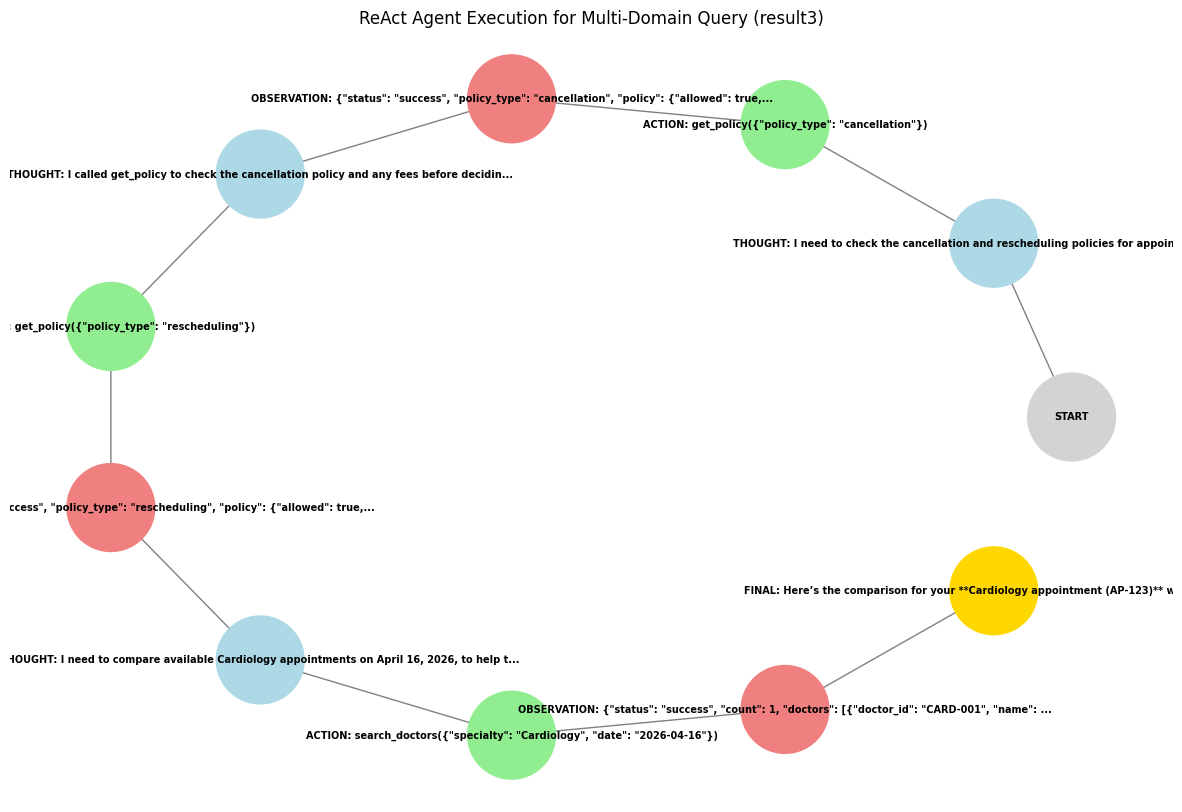


--- Graph Details ---
Nodes and their features:
  Node: START, Type: Start, Label: 'START'
  Node: T_1, Type: Thought, Label: 'THOUGHT: I need to check the cancellation and rescheduling policies for appointment AP-12...'
  Node: A_2, Type: Action, Label: 'ACTION: get_policy({"policy_type": "cancellation"})'
  Node: O_3, Type: Observation, Label: 'OBSERVATION: {"status": "success", "policy_type": "cancellation", "policy": {"allowed": true,...'
  Node: T_4, Type: Thought, Label: 'THOUGHT: I called get_policy to check the cancellation policy and any fees before decidin...'
  Node: A_5, Type: Action, Label: 'ACTION: get_policy({"policy_type": "rescheduling"})'
  Node: O_6, Type: Observation, Label: 'OBSERVATION: {"status": "success", "policy_type": "rescheduling", "policy": {"allowed": true,...'
  Node: T_7, Type: Thought, Label: 'THOUGHT: I need to compare available Cardiology appointments on April 16, 2026, to help t...'
  Node: A_8, Type: Action, Label: 'ACTION: search_doctors({"specia

In [64]:
import networkx as nx
import matplotlib.pyplot as plt
import json # Ensure json is imported for tool_calls args

# Function to build and visualize the graph from LangGraph's result messages
def visualize_agent_steps(result_messages, title="Agent Execution Graph"):
    G = nx.DiGraph()
    current_node_id = 'START'
    G.add_node(current_node_id, type='Start', label='START')
    node_counter = 0

    # Filter out the initial HumanMessage (user query) as it's the trigger, not part of the TAO loop itself
    # The TAO loop starts with the agent's first response.
    tao_messages = result_messages[1:]

    for i, msg in enumerate(tao_messages):
        msg_type_name = type(msg).__name__

        if msg_type_name == 'AIMessage':
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                # This is an agent's thought followed by an action
                thought_content = msg.content if msg.content else "Agent thought"
                action_name = msg.tool_calls[0]['name']
                action_args = json.dumps(msg.tool_calls[0]['args'])

                node_counter += 1
                thought_node_label = f"THOUGHT: {thought_content[:80]}..." if len(thought_content) > 80 else f"THOUGHT: {thought_content}"
                thought_node_id = f'T_{node_counter}'
                G.add_node(thought_node_id, type='Thought', label=thought_node_label)
                G.add_edge(current_node_id, thought_node_id, weight=1)
                current_node_id = thought_node_id

                node_counter += 1
                action_node_label = f"ACTION: {action_name}({action_args[:80]}...)" if len(action_args) > 80 else f"ACTION: {action_name}({action_args})"
                action_node_id = f'A_{node_counter}'
                G.add_node(action_node_id, type='Action', label=action_node_label)
                G.add_edge(current_node_id, action_node_id, weight=1)
                current_node_id = action_node_id

            elif msg.content:
                # This is a final answer or an intermediate message without tool calls
                node_counter += 1
                if i == len(tao_messages) - 1: # Check if it's the last message
                    final_node_label = f"FINAL: {msg.content[:80]}..." if len(msg.content) > 80 else f"FINAL: {msg.content}"
                    final_node_id = f'F_{node_counter}'
                    G.add_node(final_node_id, type='Final Answer', label=final_node_label)
                    G.add_edge(current_node_id, final_node_id, weight=1)
                    current_node_id = final_node_id
                else:
                    # This case means an AI message without tool calls but not the final one.
                    # This could be a pure thought if the agent sometimes just thinks without immediately acting.
                    thought_node_label = f"THOUGHT: {msg.content[:80]}..." if len(msg.content) > 80 else f"THOUGHT: {msg.content}"
                    thought_node_id = f'T_{node_counter}'
                    G.add_node(thought_node_id, type='Thought', label=thought_node_label)
                    G.add_edge(current_node_id, thought_node_id, weight=1)
                    current_node_id = thought_node_id

        elif msg_type_name == 'ToolMessage':
            # This is an observation
            node_counter += 1
            obs_content = msg.content if msg.content else "No observation content"
            observation_node_label = f"OBSERVATION: {obs_content[:80]}..." if len(obs_content) > 80 else f"OBSERVATION: {obs_content}"
            observation_node_id = f'O_{node_counter}'
            G.add_node(observation_node_id, type='Observation', label=observation_node_label)
            G.add_edge(current_node_id, observation_node_id, weight=1)
            current_node_id = observation_node_id

    # Add an END node if not already at a Final Answer
    if G.nodes[current_node_id].get('type') != 'Final Answer':
        G.add_node('END', type='End', label='END')
        G.add_edge(current_node_id, 'END', weight=1)

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.circular_layout(G) # Changed from spring_layout to circular_layout

    labels = nx.get_node_attributes(G, 'label')
    node_colors_map = {
        'Start': 'lightgray',
        'Thought': 'lightblue',
        'Action': 'lightgreen',
        'Observation': 'lightcoral',
        'Final Answer': 'gold',
        'End': 'lightgray'
    }
    colors = [node_colors_map[G.nodes[node]['type']] for node in G.nodes()]
    edge_weights = [G[u][v]['weight'] for u,v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=4000)
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edge_weights, arrowsize=20, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')

    plt.title(title)
    plt.axis('off')
    plt.show()

    # Print node features and edge weights
    print("\n--- Graph Details ---")
    print("Nodes and their features:")
    for node, data in G.nodes(data=True):
        print(f"  Node: {node}, Type: {data.get('type')}, Label: '{data.get('label')}'")

    print("\nEdges and their weights:")
    for u, v, data in G.edges(data=True):
        print(f"  Edge: ({u} -> {v}), Weight: {data.get('weight')}")

# Visualize result3 from the ReAct agent
visualize_agent_steps(result3['messages'], title="ReAct Agent Execution for Multi-Domain Query (result3)")

Critic Agent adds:
- **Verification** — the answer is checked before being sent to the patient
- **Feedback loop** — if score < 7, the answer is revised (Step 5: Revision)
- **Measurability** — numerical quality score (score 0-10)

Trade-off: +1-2 LLM calls (extra latency), but higher reliability on tricky queries.

Important: a nano-model **is not calibrated for evaluation tasks** — it may find non-existent issues and underscore good answers. The critic should be more powerful than the evaluated agent: if agents run on nano, the critic should run on mini or higher. Otherwise, the critic understands the answer worse than the one who wrote it.

**Rule:** in critical domains (finance, healthcare, aviation) — **always** add a Critic.

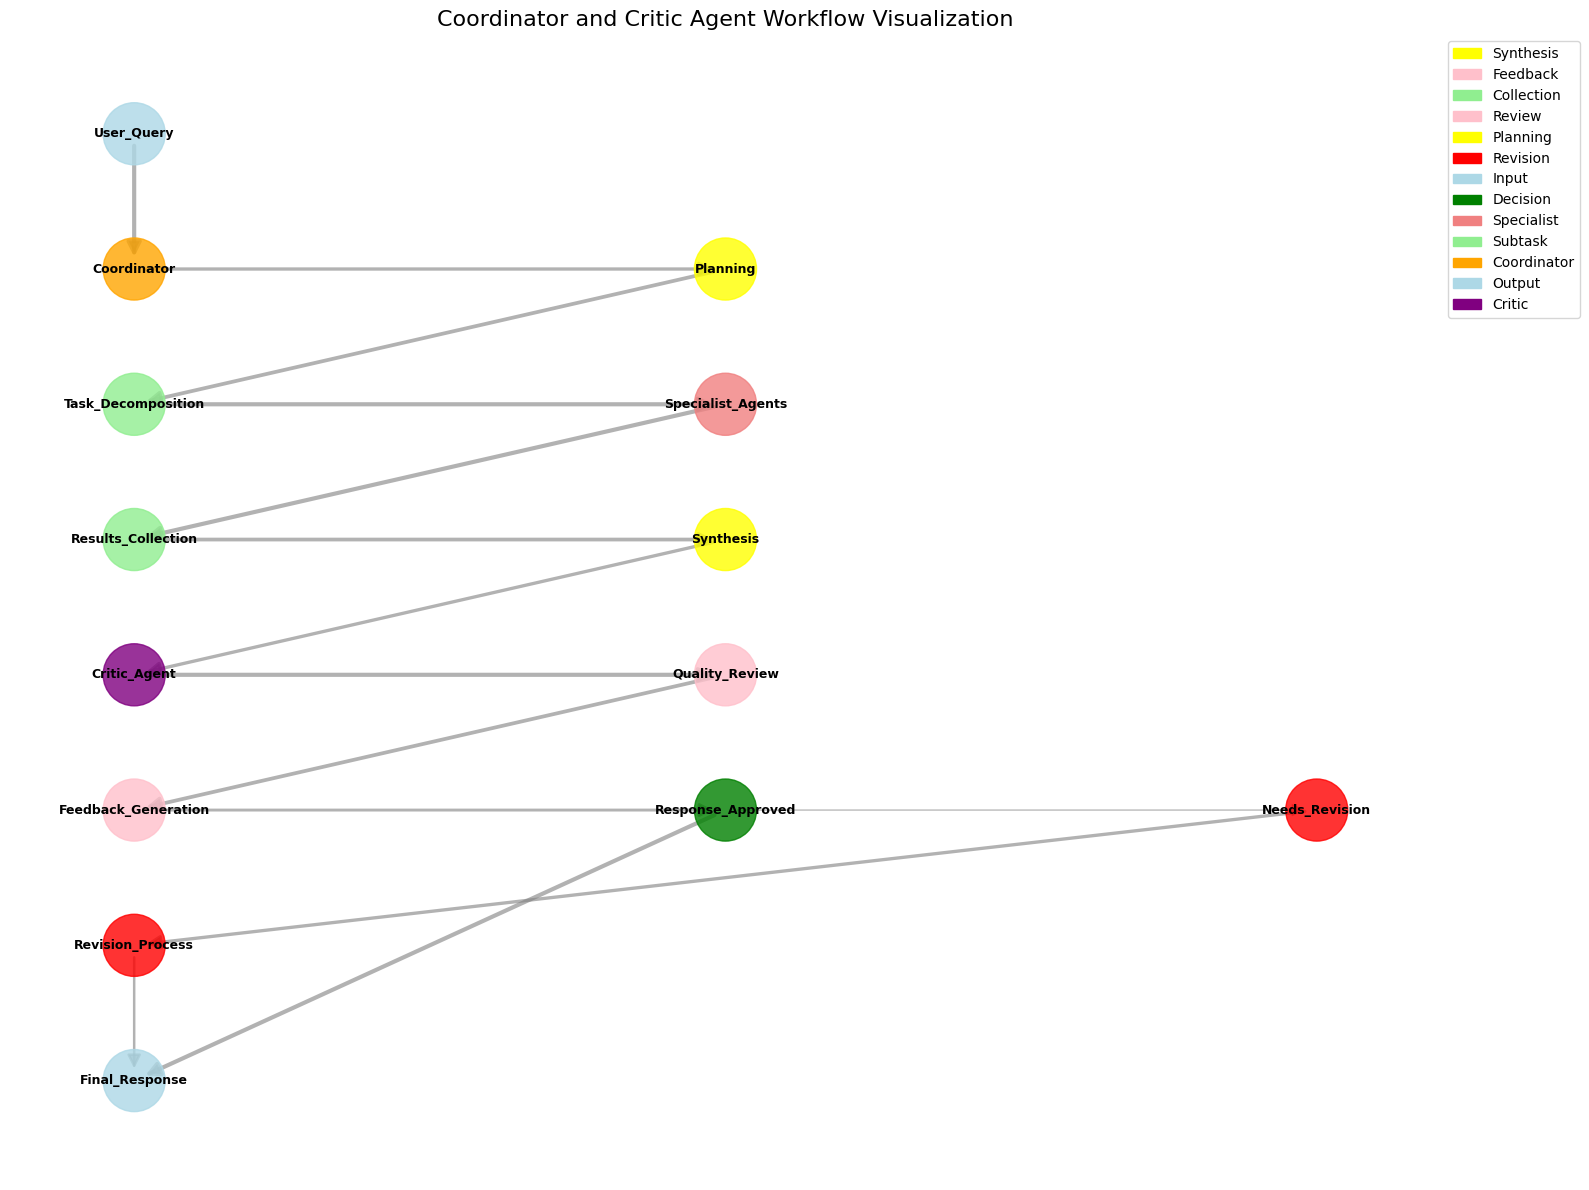

=== Workflow Graph Analysis ===
Number of nodes: 14
Number of edges: 14
Density: 0.08
Average clustering coefficient: 0.00
Longest path (potential critical path): User_Query -> Coordinator -> Planning -> Task_Decomposition -> Specialist_Agents -> Results_Collection -> Synthesis -> Critic_Agent -> Quality_Review -> Feedback_Generation -> Response_Approved -> Needs_Revision -> Revision_Process -> Final_Response
Length of longest path: 10.700000000000001

Node Degrees (Connections):
  User_Query: 1 connections
  Coordinator: 2 connections
  Planning: 2 connections
  Task_Decomposition: 2 connections
  Specialist_Agents: 2 connections
  Results_Collection: 2 connections
  Synthesis: 2 connections
  Critic_Agent: 2 connections
  Quality_Review: 2 connections
  Feedback_Generation: 2 connections
  Revision_Process: 2 connections
  Final_Response: 2 connections
  Response_Approved: 3 connections
  Needs_Revision: 2 connections

Edge Weight Statistics:
  Average weight: 0.84
  Min weight: 0.30

In [66]:
import networkx as nx
import matplotlib.pyplot as plt
from pydantic import BaseModel
from typing import List, Literal

def visualize_coordinator_critic_workflow():
    """
    Creates a NetworkX graph visualization of the Coordinator and Critic Agent workflow
    """
    G = nx.DiGraph()

    # Define node attributes
    nodes = {
        # Input nodes
        'User_Query': {'type': 'input', 'color': 'lightblue', 'shape': 'box'},

        # Coordinator nodes
        'Coordinator': {'type': 'coordinator', 'color': 'orange', 'shape': 'ellipse'},
        'Planning': {'type': 'planning', 'color': 'yellow', 'shape': 'ellipse'},
        'Task_Decomposition': {'type': 'subtask', 'color': 'lightgreen', 'shape': 'rect'},
        'Specialist_Agents': {'type': 'specialist', 'color': 'lightcoral', 'shape': 'rect'},
        'Results_Collection': {'type': 'collection', 'color': 'lightgreen', 'shape': 'rect'},
        'Synthesis': {'type': 'synthesis', 'color': 'yellow', 'shape': 'ellipse'},

        # Critic nodes
        'Critic_Agent': {'type': 'critic', 'color': 'purple', 'shape': 'ellipse'},
        'Quality_Review': {'type': 'review', 'color': 'pink', 'shape': 'rect'},
        'Feedback_Generation': {'type': 'feedback', 'color': 'pink', 'shape': 'rect'},
        'Revision_Process': {'type': 'revision', 'color': 'red', 'shape': 'rect'},

        # Output nodes
        'Final_Response': {'type': 'output', 'color': 'lightblue', 'shape': 'box'},
        'Response_Approved': {'type': 'decision', 'color': 'green', 'shape': 'diamond'},
        'Needs_Revision': {'type': 'decision', 'color': 'red', 'shape': 'diamond'},
    }

    # Add nodes with attributes
    for node, attrs in nodes.items():
        G.add_node(node, **attrs)

    # Define edges with weights (representing importance/dependency strength)
    # Removed the cyclical edge ('Revision_Process', 'Synthesis')
    edges = [
        # User query flows
        ('User_Query', 'Coordinator', {'weight': 1.0}),

        # Coordinator planning phase
        ('Coordinator', 'Planning', {'weight': 0.8}),
        ('Planning', 'Task_Decomposition', {'weight': 0.9}),
        ('Task_Decomposition', 'Specialist_Agents', {'weight': 1.0}),

        # Specialist execution
        ('Specialist_Agents', 'Results_Collection', {'weight': 1.0}),
        ('Results_Collection', 'Synthesis', {'weight': 0.9}),
        ('Synthesis', 'Critic_Agent', {'weight': 0.8}),

        # Critic evaluation
        ('Critic_Agent', 'Quality_Review', {'weight': 1.0}),
        ('Quality_Review', 'Feedback_Generation', {'weight': 0.9}),
        ('Feedback_Generation', 'Response_Approved', {'weight': 0.7}),

        # Decision flow
        ('Response_Approved', 'Final_Response', {'weight': 1.0}),  # Approved path
        ('Response_Approved', 'Needs_Revision', {'weight': 0.3}),  # Low weight for rejection path

        # Revision flow (if needed) - Leads to a separate terminal node instead of looping back
        ('Needs_Revision', 'Revision_Process', {'weight': 0.8}),
        ('Revision_Process', 'Final_Response', {'weight': 0.6}),  # Revision leads to final response after correction
    ]

    # Add edges with weights
    for edge in edges:
        source, target, attrs = edge
        G.add_edge(source, target, **attrs)

    return G

def draw_workflow_graph(G):
    """
    Draws the workflow graph with customized layout and styling
    """
    plt.figure(figsize=(16, 12))

    # Create a hierarchical layout based on node types
    pos = {}

    # Define vertical levels based on workflow stages
    level_0 = ['User_Query']  # Input
    level_1 = ['Coordinator', 'Planning']  # Coordination
    level_2 = ['Task_Decomposition', 'Specialist_Agents']  # Task breakdown
    level_3 = ['Results_Collection', 'Synthesis']  # Synthesis
    level_4 = ['Critic_Agent', 'Quality_Review']  # Critique
    level_5 = ['Feedback_Generation', 'Response_Approved', 'Needs_Revision']  # Decision
    level_6 = ['Revision_Process']  # Revision
    level_7 = ['Final_Response']  # Output

    all_levels = [level_0, level_1, level_2, level_3, level_4, level_5, level_6, level_7]

    for i, level in enumerate(all_levels):
        for j, node in enumerate(level):
            if node in G.nodes:
                pos[node] = (j * 2, -i * 2)  # Arrange horizontally at each level

    # Get node colors based on type
    node_colors = [G.nodes[node]['color'] for node in G.nodes]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.8)

    # Draw edges with varying widths based on weight
    edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray', arrows=True, arrowsize=20)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    # Create legend
    legend_elements = []
    node_types = set(nx.get_node_attributes(G, 'type').values())
    type_colors = {
        'input': 'lightblue',
        'coordinator': 'orange',
        'planning': 'yellow',
        'subtask': 'lightgreen',
        'specialist': 'lightcoral',
        'collection': 'lightgreen',
        'synthesis': 'yellow',
        'critic': 'purple',
        'review': 'pink',
        'feedback': 'pink',
        'revision': 'red',
        'output': 'lightblue',
        'decision': 'green'
    }

    import matplotlib.patches as mpatches
    for node_type in node_types:
        color = type_colors.get(node_type, 'gray')
        legend_elements.append(mpatches.Patch(color=color, label=node_type.title()))

    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

    plt.title("Coordinator and Critic Agent Workflow Visualization", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_workflow_metrics(G):
    """
    Provides metrics and analysis of the workflow graph
    """
    print("=== Workflow Graph Analysis ===")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Density: {nx.density(G):.2f}")
    print(f"Average clustering coefficient: {nx.average_clustering(G):.2f}")

    # Identify critical paths
    try:
        # Find longest path as potential critical path
        longest_path = nx.dag_longest_path(G)
        print(f"Longest path (potential critical path): {' -> '.join(longest_path)}")
        print(f"Length of longest path: {nx.dag_longest_path_length(G)}")
    except nx.NetworkXNoPath:
        print("No path found in the graph")

    # Node degrees
    print("\nNode Degrees (Connections):")
    for node, degree in G.degree():
        print(f"  {node}: {degree} connections")

    # Edge weights summary
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    print(f"\nEdge Weight Statistics:")
    print(f"  Average weight: {sum(weights)/len(weights):.2f}")
    print(f"  Min weight: {min(weights):.2f}")
    print(f"  Max weight: {max(weights):.2f}")

# Create and visualize the workflow
workflow_graph = visualize_coordinator_critic_workflow()
draw_workflow_graph(workflow_graph)
analyze_workflow_metrics(workflow_graph)

# Part 4: Benchmark and Architecture Comparison

Comparing three approaches on the same scenarios using **fact-based objective scoring** — we check whether the response contains specific expected facts (fees, appointment times, policy details).

| Architecture | Description |
|---|---|
| Single Agent (ReAct) | One agent with all tools |
| Hierarchical MAS | Coordinator + 3 specialists |
| MAS + Critic | MAS with quality control |

In [37]:
### 4.1 Preparation: Benchmark Infrastructure

# === Benchmarking System ===

import re


@dataclass
class BenchmarkResult:
    architecture: str
    query: str
    response: str
    execution_time: float
    llm_calls: int
    tool_calls: int
    success: bool
    fact_score: float = 0.0
    facts_found: list = None
    facts_missed: list = None


# Three queries of increasing complexity — each highlights a different architecture gap.
TEST_QUERIES = [
    {
        'query': 'What are the prescription refill policies?',
        'complexity': 'simple',
        'expected_tools': ['get_policy'],
    },
    {
        'query': (
            'I have appointment AP-123 (Cardiology, April 15, 2026). Should I cancel or reschedule '
            'to April 16, 2026? Compare the costs and show me available Cardiology appointments.'
        ),
        'complexity': 'multi-domain',
        'expected_tools': ['get_appointment', 'get_policy', 'get_policy', 'search_doctors'],
    },
    {
        'query': (
            'I have appointment AP-123 (Cardiology with Dr. Johnson). I want to reschedule to '
            'the latest available appointment on April 16, 2026. How much will it cost me in total?'
        ),
        'complexity': 'tricky',
        'expected_tools': ['get_appointment', 'get_policy', 'search_doctors'],
    },
]


# === Fact-Based Objective Scoring ===
# Instead of using an LLM as judge (unreliable with nano models),
# we check for presence of specific facts that a correct answer MUST contain.

EXPECTED_FACTS = {
    'simple': [
        (r'48\s*hour|48.{0,10}(notice|refill|advance)', '48-hour advance notice requirement'),
        (r'90.{0,10}days|every.{0,10}90|90.{0,10}(day|period)', '90-day prescription periods'),
        (r'controlled.{0,30}substance|every.{0,10}90.{0,10}visit|in.person.{0,20}visit', 'Controlled substance requirements'),
    ],
    'multi-domain': [
        (r'\$30|30.{0,10}(fee|cancel|charg)|cancellation.{0,15}(fee|\$|30)', 'Cancellation fee ($30)'),
        (r'\$20|20.{0,10}(fee|reschedul|charg)|rescheduling.{0,15}(fee|\$|20)', 'Rescheduling fee ($20)'),
        (r'CARD-001|Dr\..{0,10}Johnson|cardiology', 'Dr. Johnson (Cardiology) info'),
        (r'09:00|April.{0,10}15|2026-04-15', 'Current appointment time'),
        (r'(cancel|reschedul).{0,80}(reschedul|cancel)|compar|both.{0,20}option|option', 'Both options discussed'),
    ],
    'tricky': [
        (r'08:00|07:30|Pediatrics', 'Pediatrics option'),
        (r'10:00|11:30|Dermatology', 'Latest appointment Dermatology'),
        (r'(specialty|cardiology|pediatrics|dermatology).{0,40}(restrict|mismatch|not.{0,5}allow|same.specialty|cannot|only)', 'Specialty restriction flagged'),
        (r'\$?20|rescheduling.{0,10}fee', 'Rescheduling fee ($20)'),
        (r'\$?120|100.{0,20}20|20.{0,20}100|total.{0,20}(cost|\$)', 'Total cost (~$120)'),
    ],
}


def score_response(response: str, complexity: str) -> tuple:
    """Objective fact-based scoring: checks which expected facts appear in the response."""
    patterns = EXPECTED_FACTS.get(complexity, [])
    if not patterns:
        return 0.0, [], []

    text = response.lower()
    found = []
    missed = []
    for pattern, label in patterns:
        if re.search(pattern, text, re.IGNORECASE):
            found.append(label)
        else:
            missed.append(label)

    score = round(len(found) / len(patterns) * 10, 1)
    return score, found, missed


def count_messages(result_messages):
    """Counts LLM calls and tool calls from the message chain."""
    llm_calls = sum(1 for m in result_messages if type(m).__name__ == 'AIMessage')
    tool_calls = sum(
        len(m.tool_calls) for m in result_messages
        if hasattr(m, 'tool_calls') and m.tool_calls
    )
    return llm_calls, tool_calls


print(f'Benchmark ready: {len(TEST_QUERIES)} test queries')
print(f'Scoring: fact-based ({sum(len(v) for v in EXPECTED_FACTS.values())} total checkpoints)')

"""### 4.2 Running the Benchmark"""

# === Run Benchmark ===

reset_db()
all_results = []


def _benchmark_architecture(arch_name, run_fn):
    """Run all test queries for a given architecture."""
    print(f'\n{"=" * 60}')
    print(f'BENCHMARKING: {arch_name}')
    print('=' * 60)

    for tq in TEST_QUERIES:
        reset_db()
        print(f'\n  Query ({tq["complexity"]}): {tq["query"][:60]}...')
        start = time.time()
        try:
            run_fn(tq, start)
        except Exception as e:
            elapsed = time.time() - start
            all_results.append(
                BenchmarkResult(
                    architecture=arch_name,
                    query=tq['query'],
                    response=str(e),
                    execution_time=elapsed,
                    llm_calls=0,
                    tool_calls=0,
                    success=False,
                    facts_found=[],
                    facts_missed=[],
                )
            )
            print(f'  -> FAIL: {e}')


# 1. Single Agent
def _run_single(tq, start):
    result = react_agent.invoke({'messages': [HumanMessage(content=tq['query'])]})
    elapsed = time.time() - start
    llm_c, tool_c = count_messages(result['messages'])
    response_text = result['messages'][-1].content
    score, found, missed = score_response(response_text, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='Single Agent',
            query=tq['query'],
            response=response_text,
            execution_time=elapsed,
            llm_calls=llm_c,
            tool_calls=tool_c,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    print(f'  -> OK in {elapsed:.1f}s (Tools: {tool_c}, Score: {score}/10)')


_benchmark_architecture('Single Agent (ReAct)', _run_single)


# 2. Hierarchical MAS
def _run_mas(tq, start):
    answer, results = coordinator.process_query(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 2
    score, found, missed = score_response(answer, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='Hierarchical MAS',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10)')


_benchmark_architecture('Hierarchical MAS', _run_mas)


# 3. MAS + Critic
def _run_mas_critic(tq, start):
    answer, results, feedback = enhanced_coordinator.process_query_with_qc(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 3
    score, found, missed = score_response(answer, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='MAS + Critic',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    revised = 'Yes' if not feedback.approved else 'No'
    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10, Revised: {revised})')


_benchmark_architecture('MAS + Critic', _run_mas_critic)

print('\nBenchmark complete!')

"""### 4.3 Results and Analysis"""

# === Comparison Report ===

print('\n' + '=' * 80)
print('BENCHMARK REPORT: Architecture Comparison')
print('=' * 80)

# Group by architecture
architectures = {}
for r in all_results:
    architectures.setdefault(r.architecture, []).append(r)

header = f'{"Architecture":<22} {"Avg Time":>10} {"Avg Tools":>10} {"Avg Score":>10}'
print(f'\n{header}')
print('-' * 60)

arch_stats = {}
for arch_name, arch_results in architectures.items():
    successful = [r for r in arch_results if r.success]
    scores = [r.fact_score for r in successful]
    stats = {
        'avg_time': sum(r.execution_time for r in successful) / max(1, len(successful)),
        'avg_tools': sum(r.tool_calls for r in successful) / max(1, len(successful)),
        'avg_score': sum(scores) / len(scores) if scores else 0,
    }
    arch_stats[arch_name] = stats
    print(f'{arch_name:<22} {stats["avg_time"]:>9.1f}s {stats["avg_tools"]:>10.1f} {stats["avg_score"]:>8.1f}/10')

# Per-query breakdown with fact analysis
print('\n' + '=' * 80)
print('PER-QUERY BREAKDOWN (fact-based scoring)')
print('=' * 80)

for tq in TEST_QUERIES:
    q_short = tq['query'][:65]
    print(f'\n  [{tq["complexity"].upper()}] {q_short}...')
    print(f'  {"Architecture":<22} {"Score":>6} {"Time":>8} {"Tools":>6}  Facts')
    print(f'  {"-" * 70}')
    for r in all_results:
        if r.query == tq['query'] and r.success:
            n_found = len(r.facts_found) if r.facts_found else 0
            n_total = n_found + (len(r.facts_missed) if r.facts_missed else 0)
            print(
                f'  {r.architecture:<22} {r.fact_score:>4.1f}/10'
                f' {r.execution_time:>7.1f}s {r.tool_calls:>5}'
                f'  {n_found}/{n_total} facts'
            )
            if r.facts_missed:
                for m in r.facts_missed:
                    print(f'     MISSED: {m}')

# Biggest score gaps
print('\n' + '=' * 80)
print('WHERE ARCHITECTURES DIVERGE')
print('=' * 80)

for tq in TEST_QUERIES:
    query_results = [r for r in all_results if r.query == tq['query'] and r.success]
    scores = [r.fact_score for r in query_results]
    if not scores or max(scores) - min(scores) < 1:
        continue
    print(f'\n  [{tq["complexity"].upper()}] Score gap: {min(scores):.0f} -> {max(scores):.0f}')
    for r in sorted(query_results, key=lambda x: x.fact_score):
        print(f'    {r.architecture}: {r.fact_score}/10')
        if r.facts_missed:
            print(f'      Missed: {", ".join(r.facts_missed)}')
    best = max(query_results, key=lambda x: x.fact_score)
    worst = min(query_results, key=lambda x: x.fact_score)
    if 'MAS' in best.architecture and 'Single' in worst.architecture:
        reason = 'MAS decomposition guaranteed coverage of all domains'
    elif 'Critic' in best.architecture:
        reason = 'Critic caught missing facts and triggered revision'
    elif 'Single' in best.architecture:
        reason = 'Single Agent preserved full context without synthesis loss'
    else:
        reason = 'better domain coverage'
    print(f'    WHY: {reason}')

# Summary
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)

arch_names = list(arch_stats.keys())
for name in arch_names:
    s = arch_stats[name]
    print(f'  {name}: avg {s["avg_score"]:.1f}/10, {s["avg_time"]:.1f}s, {s["avg_tools"]:.0f} tools')

print('\nKey findings:')
if len(arch_names) >= 2:
    s1, s2 = arch_stats[arch_names[0]], arch_stats[arch_names[1]]
    print('  - Simple queries: Single Agent is faster and retains full context')
    print('  - Complex queries: MAS wins via guaranteed domain decomposition')
    print('  - MAS+Critic adds latency but serves as a quality safety net')

print('\nProduction Recommendation:')
print('  Simple queries (1-2 tools)  -> Single Agent (fast, same quality)')
print('  Complex queries (3+ tools)  -> Hierarchical MAS (guaranteed coverage)')
print('  Critical domains            -> MAS + Critic (quality verification)')

Benchmark ready: 3 test queries
Scoring: fact-based (13 total checkpoints)

BENCHMARKING: Single Agent (ReAct)

  Query (simple): What are the prescription refill policies?...
  -> OK in 56.3s (Tools: 1, Score: 10.0/10)

  Query (multi-domain): I have appointment AP-123 (Cardiology, April 15, 2026). Shou...
  -> FAIL: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5-nano in organization org-9x9yIg9ga6Xn0Q5N9AcfUDVt on requests per min (RPM): Limit 3, Used 3, Requested 1. Please try again in 20s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}

  Query (tricky): I have appointment AP-123 (Cardiology with Dr. Johnson). I w...
  -> FAIL: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5-nano in organization org-9x9yIg9ga6Xn0Q5N9AcfUDVt on